In [2]:
# Decision Tree
# Calculating Entropy
from math import log2

X , Y
10, 0
20, 0
30, 0
40, 1
50, 1
60, 1
70, 1
80, 1

To calculate the Entropy of column X the formula is

- ∑ (Pi + log2(Pi)) where P is probability and i is the number of possibilities (In the above example 0 and 1 values of column Y or Target)

so in the above case it is there are total of 7 values so
probability of value 0 is 3/7 where as probability of 1 is 4/7



In [3]:
-((3/7 * log2(3/7)))

0.5238824662870492

In [4]:
-((4/7 * log2(4/7)))

0.46134566974720237

In [5]:
0.52 + 0.46

0.98

0.98 Entropy means column X is completely impure as Entropy is between 0 and 1 where 1 means completely impure and 0 means pure.

We can use SkLearn datasets from SKLearn


In [41]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.tree import export_graphviz
import graphviz
import matplotlib.pyplot as plt

In [16]:
iris = load_iris()
X = iris.data
y = iris.target

In [17]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [19]:
print(f"Feature :{iris.feature_names}")

Feature :['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [22]:
print(f"Target names: {iris.target_names}")

Target names: ['setosa' 'versicolor' 'virginica']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
clf = DecisionTreeClassifier(criterion='entropy')


In [24]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [25]:
tree1 = tree.export_text(clf, feature_names=iris.feature_names)
print(tree1)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |   |--- sepal length (cm) <= 6.95
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- sepal length (cm) >  6.95
|   |   |   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- sepal width (cm) <= 3.10
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  3.10
|   |   |   |   |   |--- class: 1
|   |   |   |--- petal 

The above shows the decision tree with petal lenght is chosen as the root node. Conditions (if/else type) could be see represented as <= 2.45 e.t.c

In [26]:
tree2 = tree.export_graphviz(clf, out_file=None, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True, special_characters=True)

In [27]:
tree_structure = clf.tree_

In [31]:
n_node = tree_structure.node_count
n_node

19

In [32]:
children_left = tree_structure.children_left
print(children_left)

[ 1 -1  3  4 -1 -1  7  8 -1 10 -1 12 -1 -1 15 16 -1 -1 -1]


In [33]:
print(tree_structure.children_right)

[ 2 -1  6  5 -1 -1 14  9 -1 11 -1 13 -1 -1 18 17 -1 -1 -1]


In [34]:
print(tree_structure.feature)

[ 2 -2  2  3 -2 -2  3  2 -2  3 -2  0 -2 -2  2  1 -2 -2 -2]


In [35]:
print(f"Threshold: {tree_structure.threshold}")

Threshold: [ 2.44999999 -2.          4.75        1.65000004 -2.         -2.
  1.75        4.95000005 -2.          1.55000001 -2.          6.94999981
 -2.         -2.          4.85000014  3.10000002 -2.         -2.
 -2.        ]


In [39]:
dot_data = export_graphviz(clf, out_file=None, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True, special_characters=True)

In [42]:
graph = graphviz.Source(dot_data)


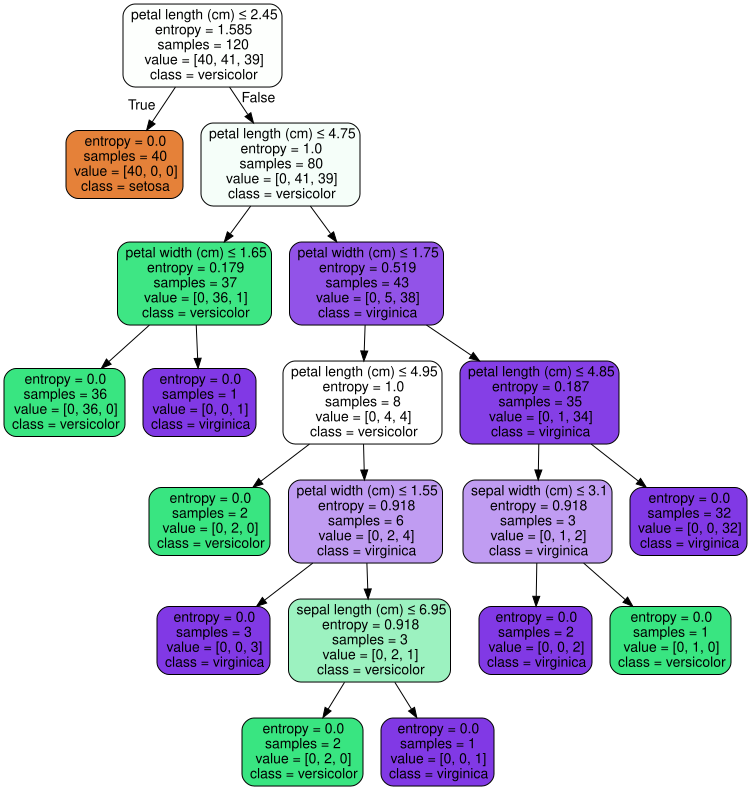

In [43]:
graph

In [44]:
graph.render("iris data visualizations", format="pdf", cleanup=True)

'iris data visualizations.pdf'

In [46]:
y_pred = clf.predict(X_test) # After model is trained, we want to predict the test data

In [48]:
accuracy_score(y_test, y_pred) # Here we want to test how much the predicted data is similar to the expected test data. The answer is 1.0 which means completely accurate.

1.0

In [49]:
confusion_matrix(y_test, y_pred)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

There are 150 Samples in IRIS data.

80% for train = 120
20% for test = 30

Above confusion_matrix explaination:

There are three classes

Setosa Virgnica Vericosa

See video lecture for explaination.

In [50]:
df = pd.read_csv('/content/diabetes.csv')

In [52]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [54]:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]

In [55]:
y = df['Outcome']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
dt = DecisionTreeClassifier(criterion='entropy')

In [58]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [59]:
dt.score(X_train, y_train)

1.0

In [60]:
dt.score(X_test, y_test)

0.7337662337662337

In [ ]:
# Sometimes Decision tree overfits.